# Analyse Exploratoire des Données (EDA) - Amazon Reviews

Ce notebook explore le dataset des avis Amazon pour comprendre :
- La distribution des sentiments
- Les caractéristiques textuelles
- Les patterns lexicaux par classe

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from nltk import ngrams
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import os

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [6]:
# Création du dossier de sortie pour les figures
os.makedirs('../outputs/figures', exist_ok=True)

# Chargement des données préparées
df = pd.read_csv('../data/prepared/p1_preprocessing.csv')

print(f"Dataset chargé : {df.shape[0]:,} lignes, {df.shape[1]} colonnes")
print(f"Colonnes : {list(df.columns)}")
df.head()

Dataset chargé : 10,000 lignes, 10 colonnes
Colonnes : ['id_ligne', 'label', 'sentiment', 'avis_brut', 'longueur_brut', 'ratio_speciaux', 'avis_nettoye', 'avis_stemme', 'nb_tokens', 'longueur_nettoye']


,id_ligne,label,sentiment,avis_brut,longueur_brut,ratio_speciaux,avis_nettoye,avis_stemme,nb_tokens,longueur_nettoye
0,3071568,2,positif,Road to getting things done: I am a great beli...,288,0.013889,road getting thing done : great believer value...,road get thing done : great believ valu employ...,28,212
1,3551227,1,negatif,The Weight Loss Cure: This would be a good boo...,165,0.024242,weight loss cure : would good book . good idea...,weight loss cure : would good book . good idea...,23,131
2,1551764,1,negatif,Royal Velvet Pillows: These pillows were over ...,171,0.017544,royal velvet pillow : pillow rated description...,royal velvet pillow : pillow rate descript ama...,18,119
3,3021401,1,negatif,Great Book For Kiddies: Robert Sawyer's books ...,260,0.026923,great book kiddy : robert sawyer 's book featu...,great book kiddi : robert sawyer 's book featu...,31,207
4,2306846,1,negatif,"Digimortal: You know, Fear Factory used to be ...",691,0.039074,"digimortal : know , fear factory used favorite...","digimort : know , fear factori use favorit ban...",84,435


##  Statistiques descriptives
   - Nombre d'avis par classe
   - Longueur moyenne, min, max
   - Distribution des longueurs
   - Vocabulaire total unique

In [7]:
# Utilisation des colonnes existantes du CSV prétraité
# Renommage pour cohérence avec le reste du notebook
df['text'] = df['avis_brut']
df['text_length'] = df['longueur_brut']
df['word_count'] = df['nb_tokens']
df['sentiment_str'] = df['sentiment']

print(f"\n Nombre total d'avis : {len(df):,}")
print(f" Nombre de colonnes : {len(df.columns)}")

print("\n--- Distribution des Classes ---")
class_dist = df['sentiment_str'].value_counts()
class_pct = df['sentiment_str'].value_counts(normalize=True) * 100
for sent in class_dist.index:
    print(f"   {sent.capitalize()}: {class_dist[sent]:,} ({class_pct[sent]:.1f}%)")

print("\n--- Statistiques de Longueur des Textes ---")
print(f"   Longueur moyenne (caractères) : {df['text_length'].mean():.1f}")
print(f"   Longueur médiane (caractères) : {df['text_length'].median():.1f}")
print(f"   Longueur min : {df['text_length'].min()}")
print(f"   Longueur max : {df['text_length'].max():,}")

print("\n--- Statistiques du Nombre de Mots ---")
print(f"   Nombre moyen de mots : {df['word_count'].mean():.1f}")
print(f"   Nombre médian de mots : {df['word_count'].median():.1f}")
print(f"   Minimum : {df['word_count'].min()}")
print(f"   Maximum : {df['word_count'].max()}")    


 Nombre total d'avis : 10,000
 Nombre de colonnes : 14

--- Distribution des Classes ---
   Positif: 5,000 (50.0%)
   Negatif: 5,000 (50.0%)

--- Statistiques de Longueur des Textes ---
   Longueur moyenne (caractères) : 430.1
   Longueur médiane (caractères) : 381.0
   Longueur min : 101
   Longueur max : 1,015

--- Statistiques du Nombre de Mots ---
   Nombre moyen de mots : 54.4
   Nombre médian de mots : 48.0
   Minimum : 7
   Maximum : 231


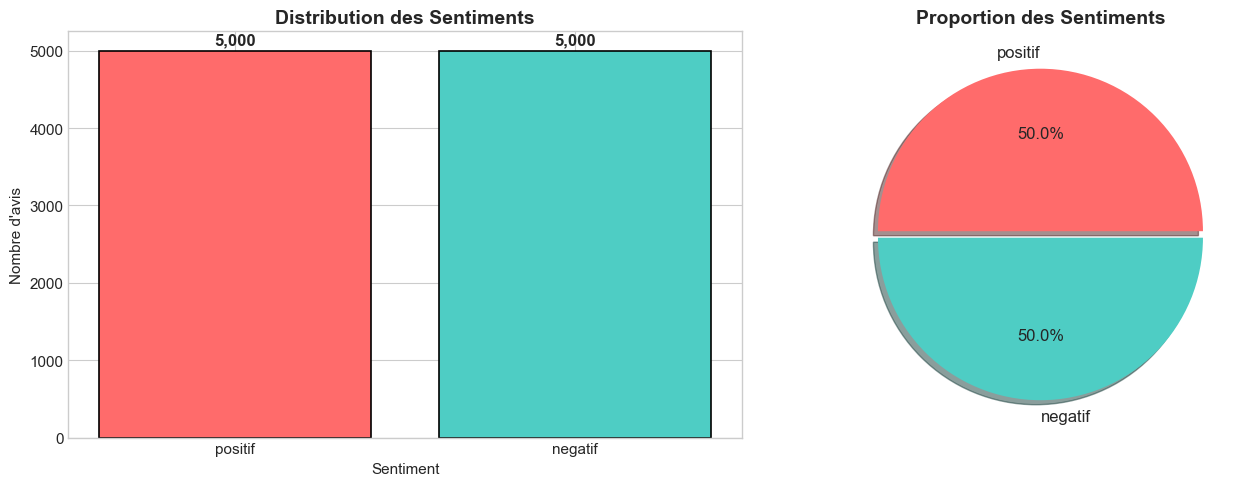

 classes relativement équilibrées (ratio 1.00:1)


In [8]:
# Visualisation de la distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Distribution des sentiments
colors = ['#FF6B6B', '#4ECDC4']
ax1 = axes[0]
bars = ax1.bar(class_dist.index, class_dist.values, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_title('Distribution des Sentiments', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Nombre d\'avis')
for bar, val in zip(bars, class_dist.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Graphique 2 : Ratio des classes (Pie chart)
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(class_dist.values, labels=class_dist.index, 
                                   autopct='%1.1f%%', colors=colors,
                                   explode=(0.02, 0.02), shadow=True,
                                   textprops={'fontsize': 12})
ax2.set_title('Proportion des Sentiments', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/01_distribution_sentiments.png', dpi=150, bbox_inches='tight')
plt.show()

# Vérification du déséquilibre
ratio = max(class_dist.values) / min(class_dist.values)
if ratio > 1.5:
    print(f"  Attention : déséquilibre de classes détecté (ratio {ratio:.2f}:1)")
    print("   Considérez des techniques de rééquilibrage (oversampling, undersampling, class_weight)")
else:
    print(f" classes relativement équilibrées (ratio {ratio:.2f}:1)")

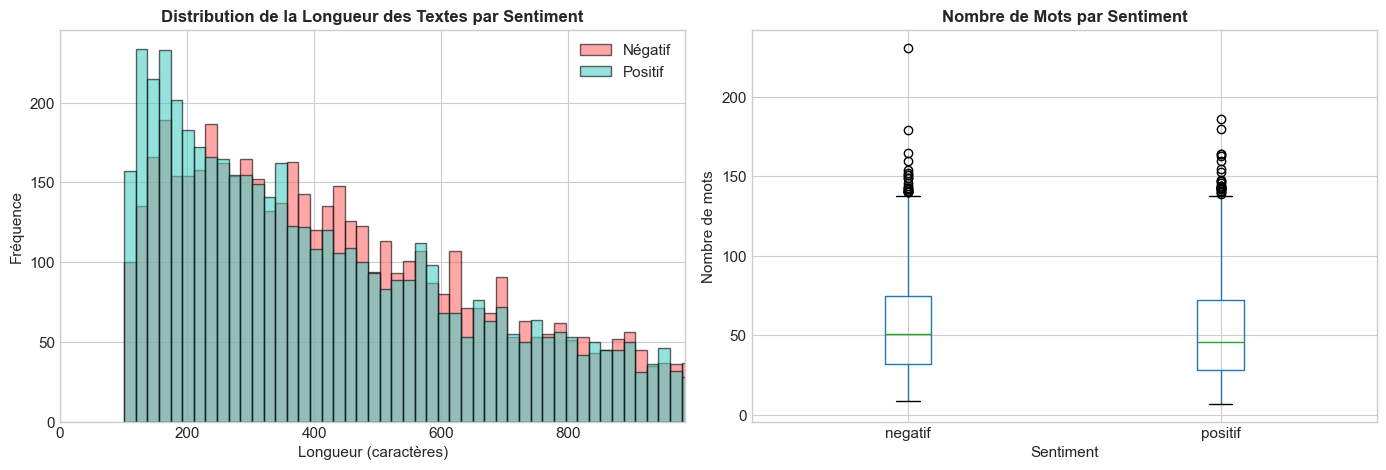


 Statistiques par sentiment :
              text_length                                                    \
                    count   mean    std    min    25%    50%    75%     max   
sentiment_str                                                                 
negatif            5000.0  443.8  234.6  101.0  249.0  401.0  606.2  1015.0   
positif            5000.0  416.4  238.3  101.0  213.0  357.5  579.0  1015.0   

              word_count                                            
                   count  mean   std  min   25%   50%   75%    max  
sentiment_str                                                       
negatif           5000.0  56.2  29.3  9.0  32.0  51.0  75.0  231.0  
positif           5000.0  52.6  30.0  7.0  28.0  46.0  72.0  186.0  


In [9]:
# Distribution des longueurs par sentiment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des longueurs
ax1 = axes[0]
for sent, color, label in zip(['negatif', 'positif'], colors, ['Négatif', 'Positif']):
    subset = df[df['sentiment'] == sent]['text_length']
    ax1.hist(subset, bins=50, alpha=0.6, color=color, label=label, edgecolor='black')
ax1.set_title('Distribution de la Longueur des Textes par Sentiment', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longueur (caractères)')
ax1.set_ylabel('Fréquence')
ax1.legend()
ax1.set_xlim(0, df['text_length'].quantile(0.99))  # Exclure les outliers extrêmes

# Boxplot comparatif
ax2 = axes[1]
df.boxplot(column='word_count', by='sentiment_str', ax=ax2)
ax2.set_title('Nombre de Mots par Sentiment', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sentiment')
ax2.set_ylabel('Nombre de mots')
plt.suptitle('')  # Supprimer le titre automatique

plt.tight_layout()
plt.savefig('../outputs/figures/02_distribution_longueurs.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistiques par sentiment
print("\n Statistiques par sentiment :")
print(df.groupby('sentiment_str')[['text_length', 'word_count']].describe().round(1))

# Analyse Textuelle Approfondie

L'analyse des n-grammes (mots, bigrammes, trigrammes) permet de :
- Identifier les **patterns lexicaux** caractéristiques de chaque classe
- Repérer les **mots discriminants** pour la classification
- Comprendre le **vocabulaire métier** du domaine

In [10]:
def get_top_ngrams(texts, n=1, top_k=20):
    """
    Extrait les n-grammes les plus fréquents d'une collection de textes.
    
    Parameters:
    -----------
    texts : list or Series
        Collection de textes
    n : int
        Taille du n-gramme (1=unigram, 2=bigram, 3=trigram)
    top_k : int
        Nombre de n-grammes à retourner
    """
    all_ngrams = []
    for text in texts:
        tokens = word_tokenize(text.lower())
        tokens = [t for t in tokens if t.isalpha()]  # Garder que les mots
        text_ngrams = list(ngrams(tokens, n))
        all_ngrams.extend(text_ngrams)
    
    # Compter et retourner les plus fréquents
    ngram_counts = Counter(all_ngrams)
    return ngram_counts.most_common(top_k)

# Analyse par sentiment
print("Analyse des mots les plus fréquents par sentiment...\n")

positive_texts = df[df['sentiment'] == 'positif']['text'].tolist()
negative_texts = df[df['sentiment'] == 'negatif']['text'].tolist()

print("--- TOP 15 MOTS POSITIFS ---")
top_positive = get_top_ngrams(positive_texts, n=1, top_k=15)
for word, count in top_positive:
    print(f"   {word[0]:15} : {count:,}")

print("\n--- TOP 15 MOTS NÉGATIFS ---")
top_negative = get_top_ngrams(negative_texts, n=1, top_k=15)
for word, count in top_negative:
    print(f"   {word[0]:15} : {count:,}")

Analyse des mots les plus fréquents par sentiment...

--- TOP 15 MOTS POSITIFS ---
   the             : 18,607
   and             : 11,264
   i               : 10,145
   a               : 10,114
   to              : 9,053
   it              : 8,281
   of              : 7,901
   is              : 7,124
   this            : 6,947
   in              : 4,665
   for             : 4,602
   you             : 3,734
   that            : 3,720
   with            : 2,936
   book            : 2,753

--- TOP 15 MOTS NÉGATIFS ---
   the             : 20,848
   i               : 12,132
   to              : 10,195
   and             : 9,957
   a               : 9,848
   it              : 9,275
   of              : 7,781
   this            : 7,613
   is              : 6,725
   not             : 4,718
   in              : 4,360
   that            : 4,296
   for             : 4,260
   was             : 4,125
   you             : 3,276


In [11]:
# Analyse des bigrammes et trigrammes
print("\n--- TOP 10 BIGRAMMES POSITIFS ---")
top_bi_pos = get_top_ngrams(positive_texts, n=2, top_k=10)
for bigram, count in top_bi_pos:
    print(f"   {' '.join(bigram):25} : {count:,}")

print("\n--- TOP 10 BIGRAMMES NÉGATIFS ---")
top_bi_neg = get_top_ngrams(negative_texts, n=2, top_k=10)
for bigram, count in top_bi_neg:
    print(f"   {' '.join(bigram):25} : {count:,}")

print("\n--- TOP 10 TRIGRAMMES POSITIFS ---")
top_tri_pos = get_top_ngrams(positive_texts, n=3, top_k=10)
for trigram, count in top_tri_pos:
    print(f"   {' '.join(trigram):30} : {count:,}")

print("\n--- TOP 10 TRIGRAMMES NÉGATIFS ---")
top_tri_neg = get_top_ngrams(negative_texts, n=3, top_k=10)
for trigram, count in top_tri_neg:
    print(f"   {' '.join(trigram):30} : {count:,}")


--- TOP 10 BIGRAMMES POSITIFS ---
   of the                    : 1,988
   is a                      : 1,268
   this book                 : 1,240
   in the                    : 1,154
   this is                   : 1,145
   it is                     : 975
   and the                   : 826
   i have                    : 816
   if you                    : 799
   for the                   : 691

--- TOP 10 BIGRAMMES NÉGATIFS ---
   of the                    : 2,042
   this book                 : 1,277
   in the                    : 1,178
   it is                     : 852
   if you                    : 850
   it was                    : 823
   i was                     : 817
   i have                    : 799
   to be                     : 768
   this is                   : 765

--- TOP 10 TRIGRAMMES POSITIFS ---
   this is a                      : 444
   one of the                     : 295
   this book is                   : 234
   is a great                     : 211
   this is the    

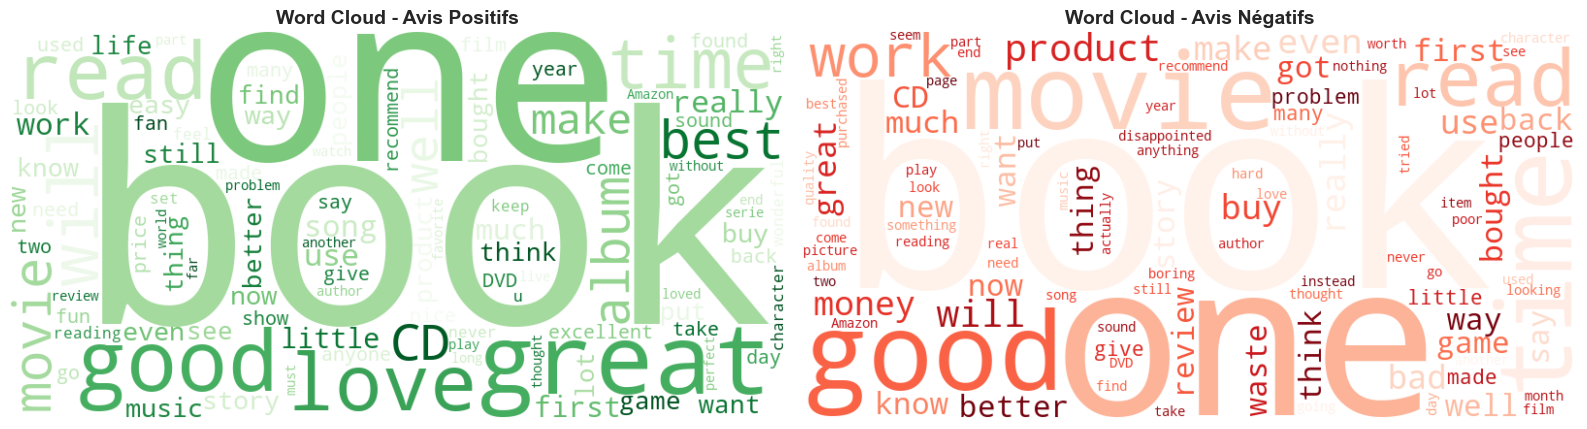

In [12]:
# Word Clouds par sentiment
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Word Cloud Positif
positive_text = ' '.join(positive_texts)
wordcloud_pos = WordCloud(width=800, height=400, background_color='white',
                          colormap='Greens', max_words=100).generate(positive_text)
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title('Word Cloud - Avis Positifs', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Word Cloud Négatif
negative_text = ' '.join(negative_texts)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white',
                          colormap='Reds', max_words=100).generate(negative_text)
axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].set_title('Word Cloud - Avis Négatifs', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/figures/03_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()